In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import numpy as np
from scipy import stats
from scipy.interpolate import CubicSpline
from sklearn.metrics import pairwise_distances
from scipy.stats import mannwhitneyu
sns.set()

In [2]:
traj = pd.read_csv('../csvs/trajectory/C1_L1.csv')

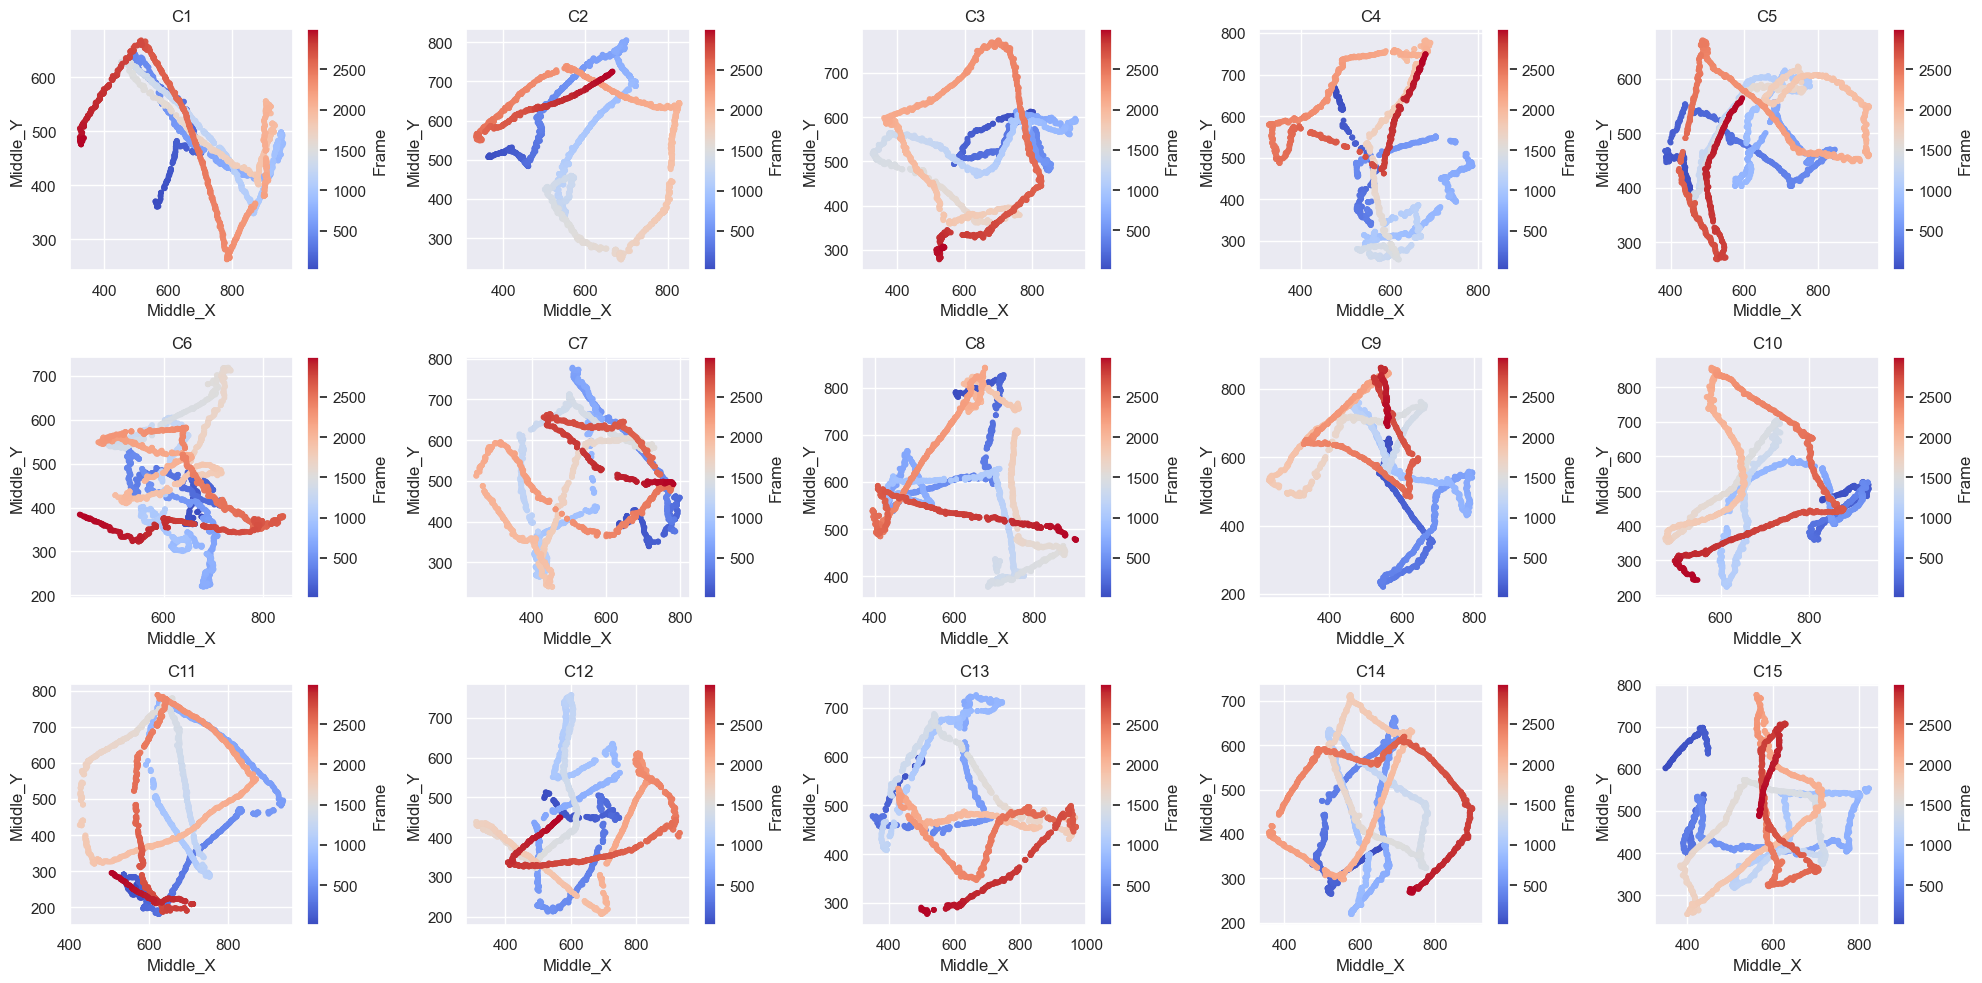

In [15]:
plt.figure(figsize=(20, 10))  # 図全体のサイズ

for num in range(1, 16):
    path = f'../csvs/trajectory/C{num}_L1.csv'
    ax = plt.subplot(3, 5, num)
    try:
        traj = pd.read_csv(path)
        traj.plot.scatter(
            x='Middle_X', y='Middle_Y',
            c='Frame',
            colormap='coolwarm',
            ax=ax,
            s=10  # 点のサイズを調整
        )
        ax.set_title(f'C{num}')
        ax.set_xlabel('Middle_X')
        ax.set_ylabel('Middle_Y')
    except Exception as e:
        pass

plt.tight_layout()
plt.show()

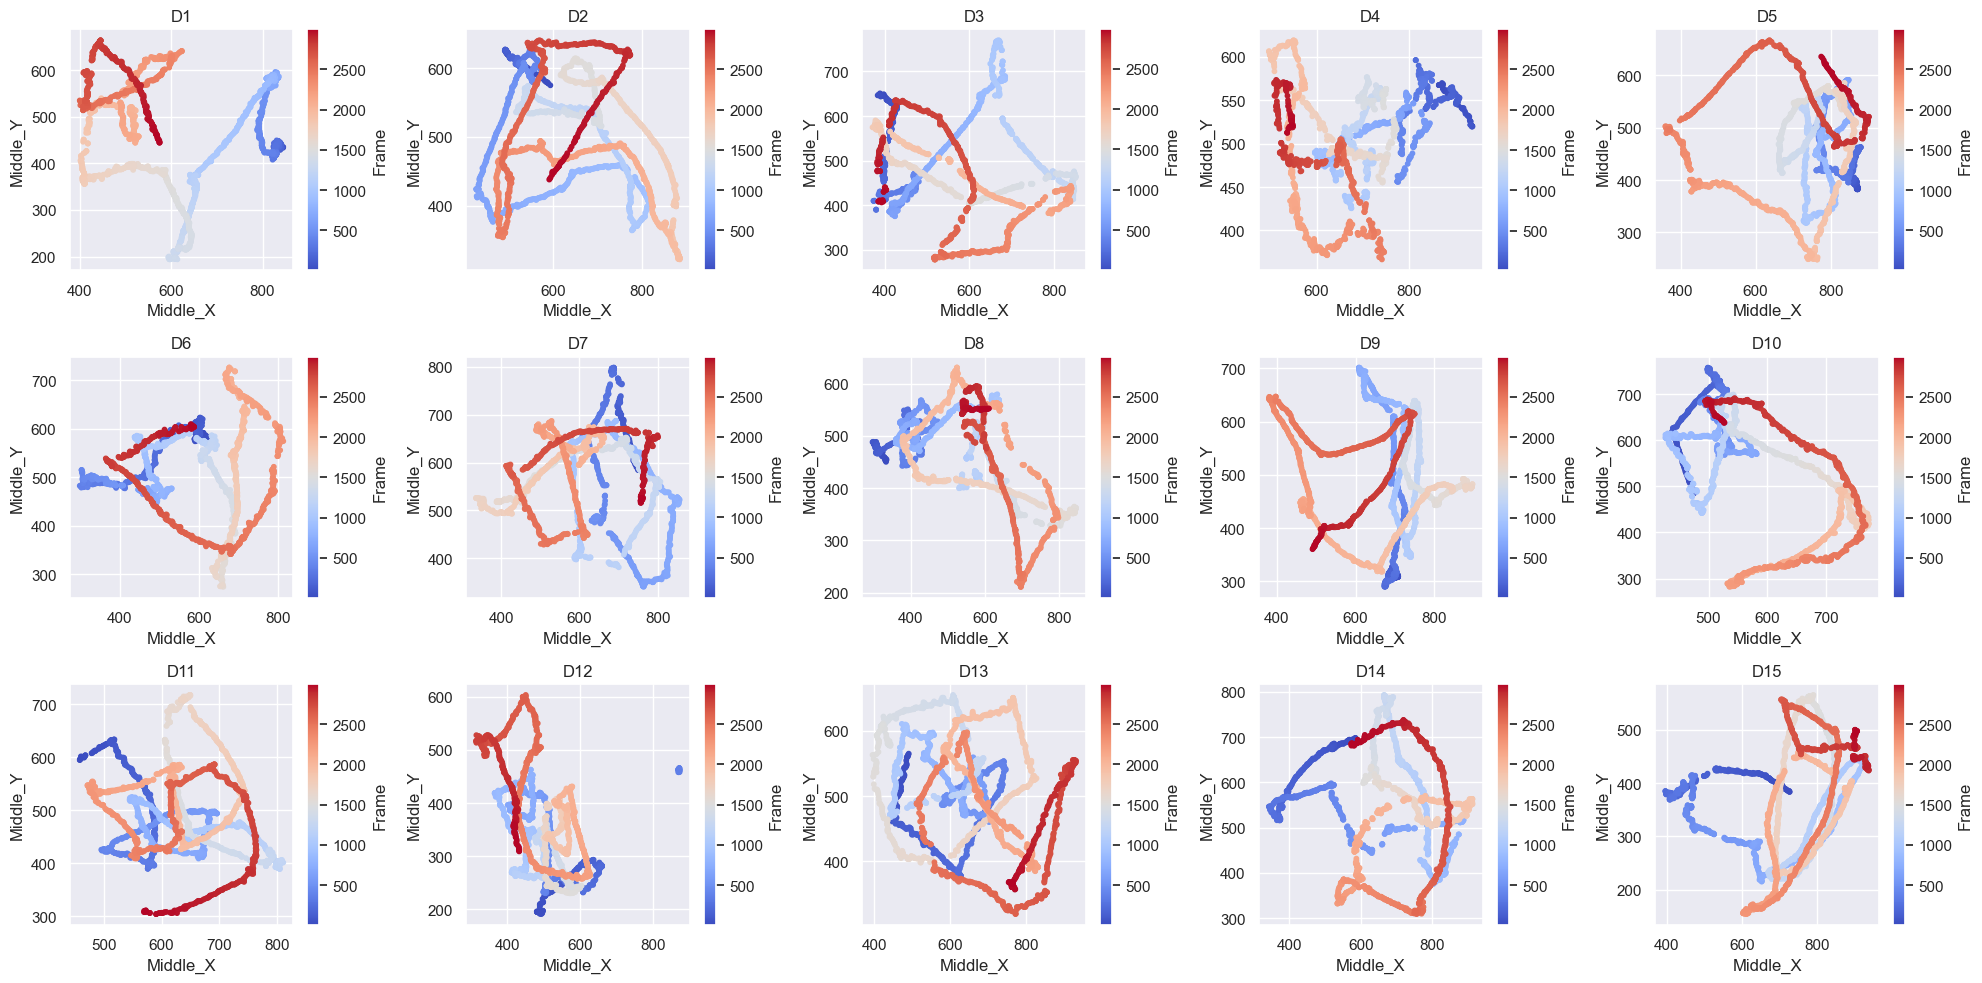

In [16]:
plt.figure(figsize=(20, 10))  # 図全体のサイズ

for num in range(1, 16):
    path = f'../csvs/trajectory/D{num}_L1.csv'
    ax = plt.subplot(3, 5, num)
    try:
        traj = pd.read_csv(path)
        traj.plot.scatter(
            x='Middle_X', y='Middle_Y',
            c='Frame',
            colormap='coolwarm',
            ax=ax,
            s=10  # 点のサイズを調整
        )
        ax.set_title(f'D{num}')
        ax.set_xlabel('Middle_X')
        ax.set_ylabel('Middle_Y')
    except Exception as e:
        pass

plt.tight_layout()
plt.show()

# Stat

=== 統計比較結果 ===
mean_velocity:
  Control mean=23.312, Mutant mean=22.404
  p-value=0.3771, Cohen's d=-0.33

linearity:
  Control mean=0.039, Mutant mean=0.034
  p-value=0.5013, Cohen's d=-0.25

mean_angle_change:
  Control mean=0.961, Mutant mean=1.013
  p-value=0.1112, Cohen's d=0.60



/tmp/ipykernel_156/3755940009.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=all_results, palette="coolwarm", ax=ax[i])
/tmp/ipykernel_156/3755940009.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='group', y=metric, data=all_results, palette="coolwarm",
/tmp/ipykernel_156/3755940009.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=all_results, palette="coolwarm", ax=ax[i])
/tmp/ipykernel_156/3755940009.py:111: FutureWarning: 

Passing `palette` without assigning `hue`

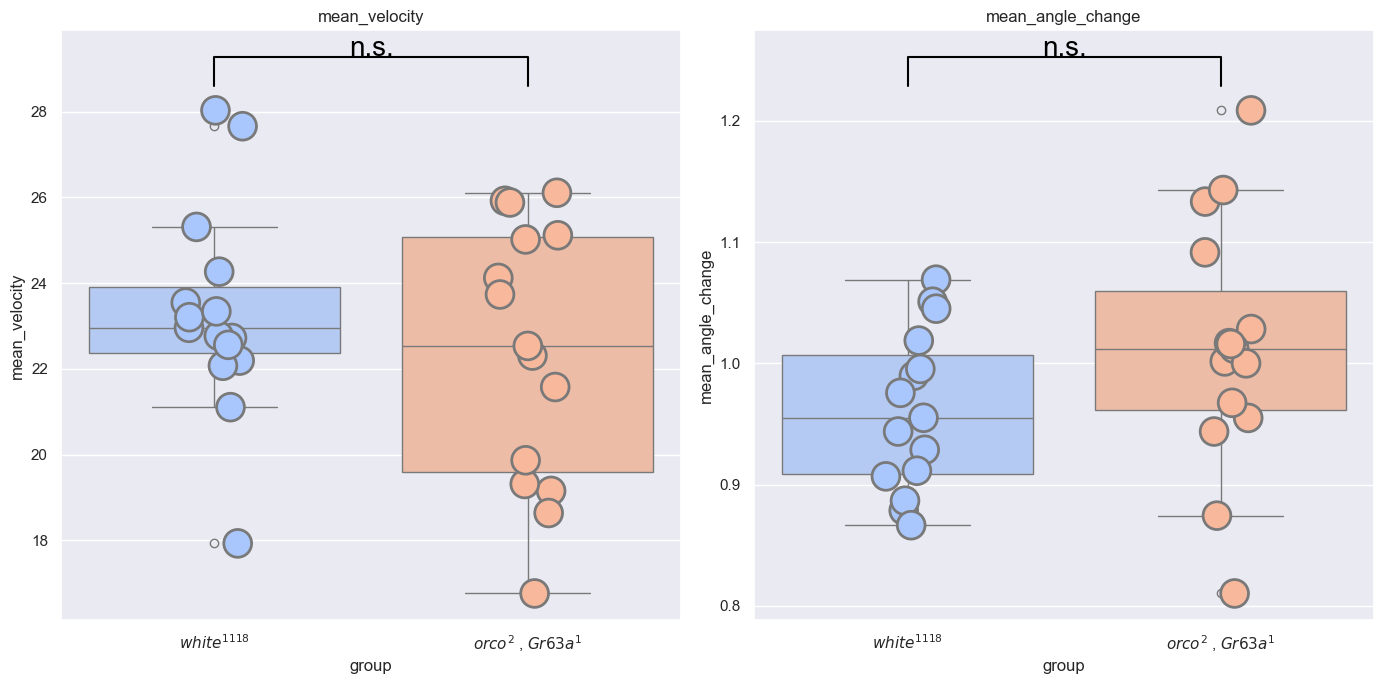

In [10]:

# ファイルリスト取得
control_files = sorted(glob.glob('../csvs/trajectory/C*_L1.csv'))
mutant_files = sorted(glob.glob('../csvs/trajectory/D*_L1.csv'))

def add_stat_annotation(ax, x1, x2, y, p_val, h):
    """
    ax: matplotlib の Axes オブジェクト
    x1, x2: 比較対象の箱（x座標；ここでは0と1と仮定）
    y: 横線の開始y座標
    p_val: 統計検定のp値
    h: オフセット（y軸方向）
    """
    color = 'black'
    # 横線の描画
    ax.plot([x1, x1, x2, x2],
            [y, y + h * 1.2, y + h * 1.2, y],
            color=color)
    # p値に応じたテキスト設定
    if p_val < 0.001:
        text = "***"
    elif p_val < 0.01:
        text = "**"
    elif p_val < 0.05:
        text = "*"
    else:
        text = "n.s."
    # 横線中央上部にテキストを描画
    ax.text((x1 + x2) * 0.5, y + h, text,
            ha='center', va='bottom', color=color, fontsize=20)

def interpolate_trajectory(df):
    """欠損値を3次スプラインで補間"""
    valid_idx = df[['Middle_X','Middle_Y']].dropna().index
    if len(valid_idx) < 3:
        df['x_interp'] = df['Middle_X']
        df['y_interp'] = df['Middle_Y']
        return df
    x_interp = CubicSpline(valid_idx, df.loc[valid_idx, 'Middle_X'])
    y_interp = CubicSpline(valid_idx, df.loc[valid_idx, 'Middle_Y'])
    df['x_interp'] = x_interp(df.index)
    df['y_interp'] = y_interp(df.index)
    return df

def calculate_metrics(df, fps=10):
    """速度・直線性・方向変化を算出"""
    df = df.copy()
    dx = np.diff(df['x_interp'], prepend=np.nan)
    dy = np.diff(df['y_interp'], prepend=np.nan)
    df['velocity'] = np.sqrt(dx**2 + dy**2) * fps

    total_dist = np.nansum(np.sqrt(np.diff(df['x_interp'])**2 + np.diff(df['y_interp'])**2))
    start_end_dist = np.sqrt((df['x_interp'].iloc[-1] - df['x_interp'].iloc[0])**2 +
                             (df['y_interp'].iloc[-1] - df['y_interp'].iloc[0])**2)
    linearity = start_end_dist / total_dist if total_dist > 0 else np.nan

    angles = np.arctan2(np.diff(df['y_interp']), np.diff(df['x_interp']))
    angle_changes = np.abs(np.diff(angles, append=np.nan))
    angle_changes = np.where(angle_changes > np.pi, 2*np.pi - angle_changes, angle_changes)
    mean_angle_change = np.nanmean(angle_changes)

    return {
        'mean_velocity': np.nanmean(df['velocity']),
        'linearity': linearity,
        'mean_angle_change': mean_angle_change
    }

def process_files(file_list, group_name):
    results = []
    for f in file_list:
        df = pd.read_csv(f)
        df = interpolate_trajectory(df)
        metrics = calculate_metrics(df)
        metrics['sample'] = f.split('/')[-1]
        metrics['group'] = group_name
        results.append(metrics)
    return pd.DataFrame(results)

# 各群のデータ集計
control_results = process_files(control_files, '$\mathit{white^{1118}}$', )
mutant_results = process_files(mutant_files, '$\mathit{orco^2}$ , $\mathit{Gr63a^1}$')

# まとめて1つのDataFrameに
all_results = pd.concat([control_results, mutant_results], ignore_index=True)

# 統計比較
def ttest_and_report(metric):
    c = control_results[metric]
    m = mutant_results[metric]
    t, p = stats.ttest_ind(c, m, equal_var=False)
    cohens_d = (m.mean() - c.mean()) / np.sqrt((c.std()**2 + m.std()**2)/2)
    print(f"{metric}:")
    print(f"  Control mean={c.mean():.3f}, Mutant mean={m.mean():.3f}")
    print(f"  p-value={p:.4f}, Cohen's d={cohens_d:.2f}\n")
    return t, p, cohens_d

print("=== 統計比較結果 ===")
for metric in ['mean_velocity', 'linearity', 'mean_angle_change']:
    ttest_and_report(metric)




#metrics = ['mean_velocity', 'linearity', 'mean_angle_change']
metrics = ['mean_velocity',  'mean_angle_change']
#metrics = ['mean_velocity']

fig, ax = plt.subplots(1, len(metrics), figsize=(7 * len(metrics), 7))

for i, metric in enumerate(metrics):
    sns.boxplot(x='group', y=metric, data=all_results, palette="coolwarm", ax=ax[i])
    sns.stripplot(x='group', y=metric, data=all_results, palette="coolwarm",
                  s=20, linewidth=2, ax=ax[i])
    ax[i].set_title(metric)


    y_max = all_results[metric].max()
    y_min = all_results[metric].min()
    h_offset = (y_max - y_min) * 0.05

    control_values = all_results[metric].dropna().values
    mutant_values  = all_results[metric].dropna().values
    stat, p_val = mannwhitneyu(control_values, mutant_values, alternative='two-sided')


    add_stat_annotation(ax[i], 0, 1, y_max + h_offset, p_val, h_offset)

plt.tight_layout()
plt.show()


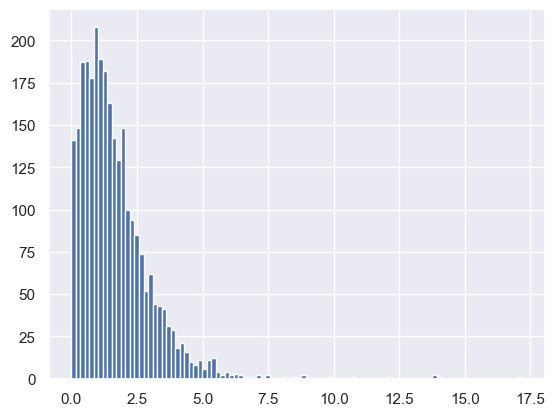

In [43]:
plt.hist(traj['DistMoved'], bins = 100)
plt.show()

In [47]:
traj_ =interpolate_trajectory(traj)
calculate_metrics(traj_)

{'mean_velocity': 16.7600149876346,
 'linearity': 0.04697799147996023,
 'mean_angle_change': 0.8101972015043323}

In [51]:
traj_['DistMoved'].sum()

4651.0895450580865

In [52]:
traj_

,Frame,ID,Head_X,Head_Y,Middle_X,Middle_Y,Tail_X,Tail_Y,Angle,DistMoved,x_interp,y_interp
0,4,1,723.35156,279.32745,705.82910,311.24260,678.46436,338.46426,16.381977,3.378109,705.82910,311.24260
1,5,1,723.31910,279.57860,706.31757,309.68410,679.17870,335.39450,17.093482,1.633256,706.31757,309.68410
2,6,1,724.53845,280.35240,706.28480,309.89026,678.84985,335.30760,15.471147,0.208736,706.28480,309.89026
3,7,1,723.69060,279.57568,706.62915,310.09412,678.80896,335.52988,18.356043,0.400177,706.62915,310.09412
4,8,1,728.57000,281.32187,707.10614,310.30698,678.39197,335.45953,12.262393,0.522330,707.10614,310.30698
...,...,...,...,...,...,...,...,...,...,...,...,...
2802,2994,1,466.61282,327.92276,495.17798,365.62054,524.43010,395.89554,6.862899,0.781920,495.17798,365.62054
2803,2995,1,464.58524,325.02130,493.79395,364.24445,524.14580,395.69025,7.311476,1.951716,493.79395,364.24445
2804,2996,1,461.94370,323.92813,492.69528,363.19858,522.99854,394.94128,5.607521,1.516872,492.69528,363.19858
2805,2997,1,460.80518,322.66812,491.44028,361.97473,522.53046,393.97458,6.241553,1.752951,491.44028,361.97473
